# CIFAR-10 Preprocessing V2
- Denoising → CLAHE → Sharpening on original 32×32
- Data Augmentation: 10K → 15K images
- No upscaling — keep original resolution

In [11]:
%pip install scipy numpy matplotlib pillow scikit-learn opencv-python

Note: you may need to restart the kernel to use updated packages.


## 1. Load Dataset (10K subset)

In [12]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
import cv2
import os

DATA_DIR = '.'

meta = scipy.io.loadmat(os.path.join(DATA_DIR, 'batches.meta.mat'))
label_names = [name[0] for name in meta['label_names'].flatten()]
print('Classes:', label_names)

# Load 1 training batch (10,000 images)
batch = scipy.io.loadmat(os.path.join(DATA_DIR, 'data_batch_1.mat'))
train_data = batch['data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.uint8)
train_labels = batch['labels'].flatten()

# Load test set (2,000 images)
test_batch = scipy.io.loadmat(os.path.join(DATA_DIR, 'test_batch.mat'))
test_data = test_batch['data'][:2000].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.uint8)
test_labels = test_batch['labels'].flatten()[:2000]

print(f'Train: {train_data.shape} | Test: {test_data.shape}')

Classes: [np.str_('airplane'), np.str_('automobile'), np.str_('bird'), np.str_('cat'), np.str_('deer'), np.str_('dog'), np.str_('frog'), np.str_('horse'), np.str_('ship'), np.str_('truck')]
Train: (10000, 32, 32, 3) | Test: (2000, 32, 32, 3)


## 2. Denoising → CLAHE → Sharpening Pipeline

In [ ]:
def preprocess_image(img):
    """Apply: Gaussian Denoising -> CLAHE -> Unsharp Masking"""
    
    # Step 1: Gaussian Denoising
    denoised = cv2.GaussianBlur(img, (3, 3), 0.5)
    
    # Step 2: CLAHE (on each channel)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    channels = cv2.split(denoised)
    clahe_channels = [clahe.apply(ch) for ch in channels]
    clahe_img = cv2.merge(clahe_channels)
    
    # Step 3: Unsharp Masking (sharpen edges)
    blurred = cv2.GaussianBlur(clahe_img, (3, 3), 1.0)
    sharpened = cv2.addWeighted(clahe_img, 1.5, blurred, -0.5, 0)
    
    return sharpened

def preprocess_batch(images):
    """Apply preprocessing to all images"""
    processed = np.zeros_like(images)
    for i in range(len(images)):
        processed[i] = preprocess_image(images[i])
        if (i + 1) % 2000 == 0:
            print(f'  Processed {i + 1}/{len(images)}')
    return processed

print('Preprocessing training images...')
train_processed = preprocess_batch(train_data)
print('Preprocessing test images...')
test_processed = preprocess_batch(test_data)
print('Done!')

Preprocessing training images...


NameError: name 'clahe_img' is not defined

## 3. Before vs After Comparison

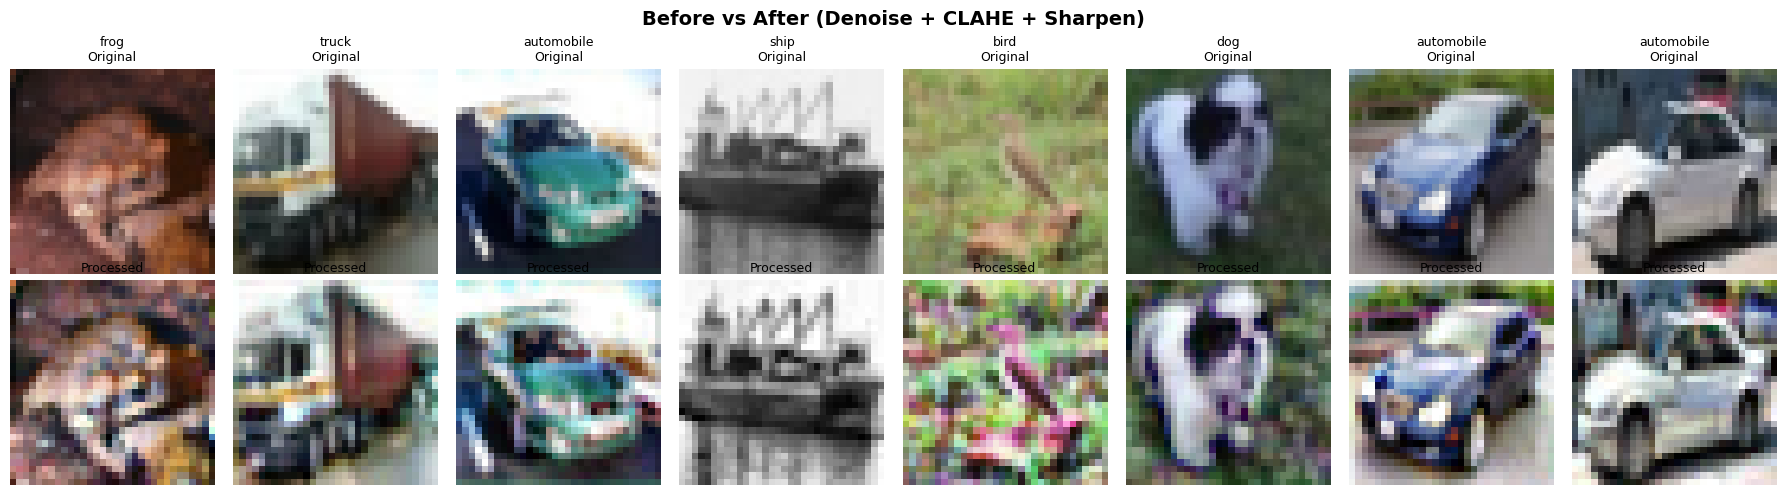

In [19]:
np.random.seed(42)
sample_idx = np.random.choice(len(train_data), 8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Before vs After (Denoise + CLAHE + Sharpen)', fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_idx):
    axes[0, i].imshow(train_data[idx])
    axes[0, i].set_title(f'{label_names[train_labels[idx]]}\nOriginal', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(train_processed[idx])
    axes[1, i].set_title('Processed', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('before_after_v2.png', dpi=150)
plt.show()

## 4. Data Augmentation (10K → 15K)

In [ ]:
def augment_image(img):
    """Apply random augmentation to create a new image"""
    aug = img.copy()
    
    # Random horizontal flip (50% chance)
    if np.random.random() > 0.5:
        aug = np.fliplr(aug)
    
    # Random rotation (-15 to +15 degrees)
    angle = np.random.uniform(-15, 15)
    h, w = aug.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    aug = cv2.warpAffine(aug, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    
    # Random crop (pad 4px, then crop back to 32x32)
    padded = np.pad(aug, ((4, 4), (4, 4), (0, 0)), mode='reflect')
    x = np.random.randint(0, 8)
    y = np.random.randint(0, 8)
    aug = padded[y:y+32, x:x+32]
    
    # Random brightness adjustment
    factor = np.random.uniform(0.8, 1.2)
    aug = np.clip(aug * factor, 0, 255).astype(np.uint8)
    
    return aug

# Generate 5,000 augmented images (10K -> 15K)
NUM_AUGMENTED = 5000
np.random.seed(42)

# Sample indices to augment (balanced across classes)
aug_images = []
aug_labels = []
samples_per_class = NUM_AUGMENTED // 10  # 500 per class

for cls in range(10):
    cls_indices = np.where(train_labels == cls)[0]
    chosen = np.random.choice(cls_indices, samples_per_class, replace=True)
    for idx in chosen:
        aug_img = augment_image(train_processed[idx])
        aug_images.append(aug_img)
        aug_labels.append(cls)

aug_images = np.array(aug_images)
aug_labels = np.array(aug_labels)

# Combine original + augmented
train_final = np.concatenate([train_processed, aug_images])
labels_final = np.concatenate([train_labels, aug_labels])

# Shuffle
shuffle_idx = np.random.permutation(len(train_final))
train_final = train_final[shuffle_idx]
labels_final = labels_final[shuffle_idx]

print(f'Original:  {train_processed.shape[0]} images')
print(f'Augmented: {aug_images.shape[0]} images')
print(f'Total:     {train_final.shape[0]} images')
print(f'Shape:     {train_final.shape}')

Original:  10000 images
Augmented: 5000 images
Total:     15000 images
Shape:     (15000, 32, 32, 3)


## 5. Show Augmented Samples

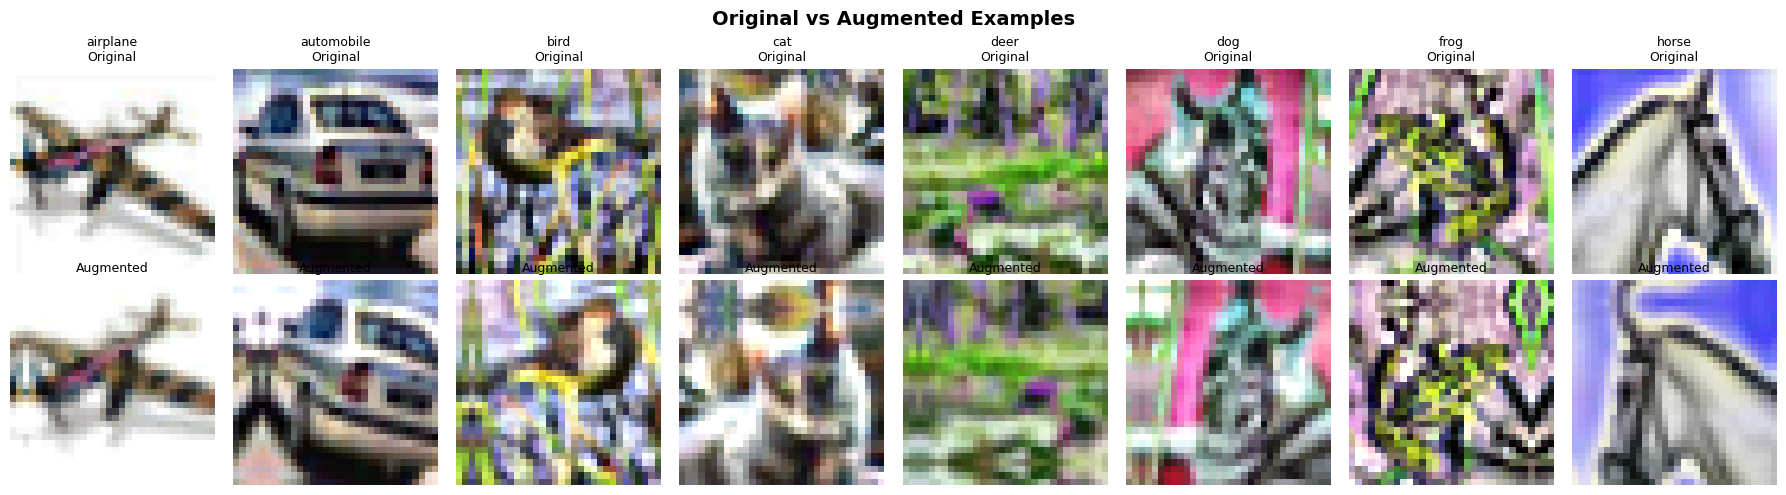

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Original vs Augmented Examples', fontsize=14, fontweight='bold')

for i in range(8):
    idx = np.random.choice(np.where(train_labels == i)[0])
    
    axes[0, i].imshow(train_processed[idx])
    axes[0, i].set_title(f'{label_names[i]}\nOriginal', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(augment_image(train_processed[idx]))
    axes[1, i].set_title('Augmented', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150)
plt.show()

## 6. Class Distribution (After Augmentation)

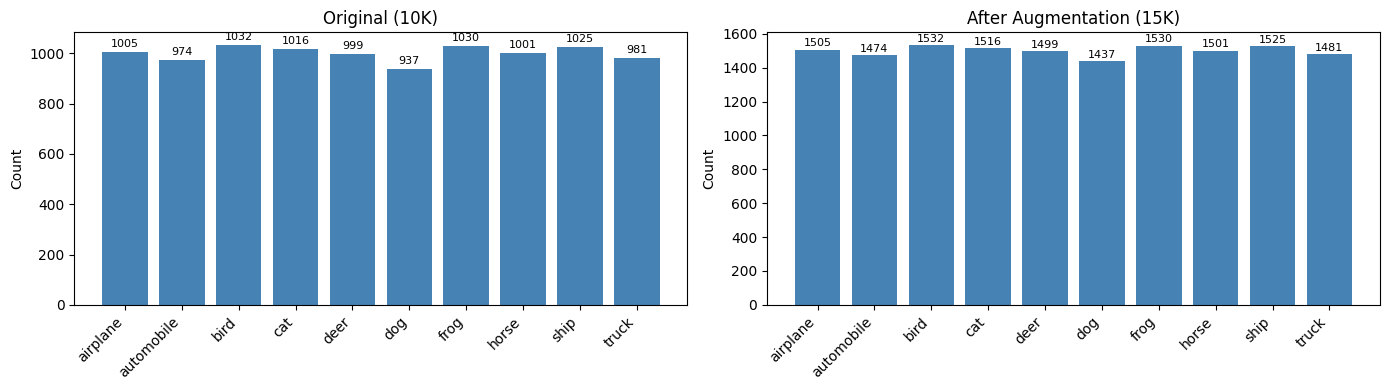

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, labels, title in zip(axes, [train_labels, labels_final], ['Original (10K)', 'After Augmentation (15K)']):
    counts = np.bincount(labels)
    ax.bar(range(10), counts, color='steelblue')
    ax.set_xticks(range(10))
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_ylabel('Count')
    ax.set_title(title)
    for j, c in enumerate(counts):
        ax.text(j, c + 20, str(c), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution_v2.png', dpi=150)
plt.show()

## 7. Normalize & Standardize

In [ ]:
# Normalize to [0, 1]
train_norm = train_final.astype(np.float32) / 255.0
test_norm = test_processed.astype(np.float32) / 255.0

# Per-channel standardization
channel_mean = train_norm.mean(axis=(0, 1, 2))
channel_std = train_norm.std(axis=(0, 1, 2))
print(f'Channel means (R,G,B): {channel_mean}')
print(f'Channel stds  (R,G,B): {channel_std}')

train_std = (train_norm - channel_mean) / channel_std
test_std = (test_norm - channel_mean) / channel_std

print(f'\nTrain - min: {train_std.min():.3f}, max: {train_std.max():.3f}, mean: {train_std.mean():.6f}')
print(f'Test  - min: {test_std.min():.3f}, max: {test_std.max():.3f}, mean: {test_std.mean():.6f}')

Channel means (R,G,B): [0.52557397 0.52484673 0.50636244]
Channel stds  (R,G,B): [0.2563429  0.25601816 0.26226702]

Train - min: -2.050, max: 1.882, mean: -0.002794
Test  - min: -2.050, max: 1.882, mean: 0.017491


## 8. Train / Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_std, labels_final,
    test_size=0.2, random_state=42, stratify=labels_final
)

X_test = test_std
y_test = test_labels

print(f'Training set:   {X_train.shape} | Labels: {y_train.shape}')
print(f'Validation set: {X_val.shape}  | Labels: {y_val.shape}')
print(f'Test set:       {X_test.shape}  | Labels: {y_test.shape}')

Training set:   (12000, 32, 32, 3) | Labels: (12000,)
Validation set: (3000, 32, 32, 3)  | Labels: (3000,)
Test set:       (2000, 32, 32, 3)  | Labels: (2000,)


## 9. Save Preprocessed Data

In [ ]:
np.savez_compressed('cifar10_v2_preprocessed.npz',
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    channel_mean=channel_mean, channel_std=channel_std,
    label_names=label_names
)

file_size = os.path.getsize('cifar10_v2_preprocessed.npz') / (1024**2)
print(f'Saved: cifar10_v2_preprocessed.npz ({file_size:.1f} MB)')
print(f'\nTo load later:')
print(f"  data = np.load('cifar10_v2_preprocessed.npz')")
print(f"  X_train, y_train = data['X_train'], data['y_train']")

Saved: cifar10_v2_preprocessed.npz (75.9 MB)

To load later:
  data = np.load('cifar10_v2_preprocessed.npz')
  X_train, y_train = data['X_train'], data['y_train']


## Summary

| Step | Details |
|---|---|
| Dataset | 1 batch (10K) + 5K augmented = **15K total** |
| Resolution | Original 32×32 (no upscaling) |
| Denoising | Gaussian blur (3×3, σ=0.5) |
| Contrast | CLAHE (clipLimit=2.0, tile=4×4) |
| Sharpening | Unsharp masking (1.5x sharpen) |
| Augmentation | Flip + Rotation + Crop + Brightness |
| Normalize | [0,255] → [0,1] + per-channel standardize |
| Split | 12K train / 3K val / 2K test |